# Quiz 3 Starter Code

You can use this notebook to answer the questions in quiz 3, on Decision Trees and Random forests.

Features:
- `median_income` – median income in that block group
- `pct_broadband` – percentage with access to broadband
- `pct_white` / `pct_black` – racial composition of the block group
- `pop_density` – population per square kilometer
- `max_speed` – maximum contractual downstream speed offered
- `num_isp` – number of unique ISPs offering service
- `num_broadband` – number of ISPs offering ≥25/3 Mbps (FCC broadband definition)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
    PrecisionRecallDisplay
)

df = pd.read_csv("../data/fcc_acs.csv")
print(df.shape)
df.head()

(2194, 8)


,median_income,pct_broadband,pct_white,pct_black,pop_density,max_speed,num_isp,num_broadband
0,-666666666,0.725806,0.568228,0.291242,7.231430e+13,0.0,7,0
1,21222,0.400211,0.348657,0.632226,1.095745e+14,1000.0,9,1
2,64517,0.829616,0.585060,0.302617,1.257709e+14,1000.0,9,2
3,44239,0.747041,0.331192,0.529622,1.343633e+14,0.0,7,0
4,31194,0.599471,0.531407,0.318844,1.485431e+14,1000.0,9,1


---
## Question 1 – Decision Tree GridSearch

Train a Decision Tree classifier to predict broadband access (`has_broadband`).  
Tune with a hyperparameter grid and 10-fold CV.

In [2]:
# ── Step 1: Train / Test Split ────────────────────────────────────────────────
train, test = train_test_split(df, test_size=0.2, random_state=0)
print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 1755, Test size: 439


In [3]:
# ── Step 2: Preprocessing ─────────────────────────────────────────────────────
FEATURES = ['pct_white', 'pct_black', 'median_income', 'pop_density', 'num_isp']
MISSING_CODE = -666666666

train = train.copy()
test  = test.copy()

# Replace the administrative missing-value code with NaN
train['median_income'] = train['median_income'].replace(MISSING_CODE, np.nan)
test['median_income']  = test['median_income'].replace(MISSING_CODE, np.nan)

# Impute missing values using the training-set column means
col_means = train[FEATURES].mean()
train[FEATURES] = train[FEATURES].fillna(col_means)
test[FEATURES]  = test[FEATURES].fillna(col_means)

# Sanity checks (should be ~60906 and ~57194)
print("Train median_income mean:", round(train['median_income'].mean(), 0))
print("Test  median_income mean:", round(test['median_income'].mean(), 0))

Train median_income mean: 60906.0
Test  median_income mean: 57194.0


In [4]:
# ── Step 3: Create Binary Target ─────────────────────────────────────────────
train['has_broadband'] = (train['num_broadband'] > 0).astype(int)
test['has_broadband']  = (test['num_broadband'] > 0).astype(int)

X_train, y_train = train[FEATURES], train['has_broadband']
X_test,  y_test  = test[FEATURES],  test['has_broadband']

print("Class balance (train):", y_train.value_counts().to_dict())

Class balance (train): {1: 887, 0: 868}


In [5]:
# ── Step 4: GridSearchCV – Decision Tree ──────────────────────────────────────
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

k = 10

params = {
    'criterion':         ('gini', 'entropy'),
    'max_depth':         (1, 3, 5),
    'min_samples_split': (2, 5, 10),
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    params, cv=k, scoring='accuracy'
)
gs_dt.fit(X_train, y_train)

print("Best parameters :", gs_dt.best_params_)
print("Best CV accuracy :", round(gs_dt.best_score_, 4))

Best parameters : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Best CV accuracy : 0.7869


**Answer Q1:** The best mean test (CV) accuracy is approximately **0.7869** (78.7 %).

---
## Question 2 – Most Important Feature

For the tree with `criterion='entropy'`, `max_depth=3`, `min_samples_split=10`.

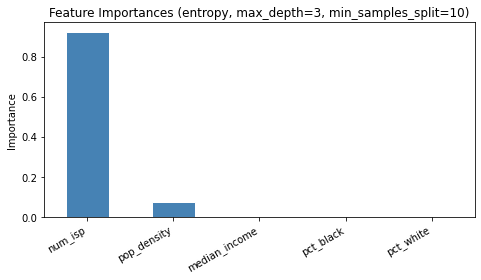


Importances:
 num_isp          0.924068
pop_density      0.075932
median_income    0.000000
pct_black        0.000000
pct_white        0.000000
dtype: float64

Most important feature: num_isp


In [6]:
# Train the specific tree
dt_q2 = DecisionTreeClassifier(
    criterion='entropy', max_depth=3, min_samples_split=10, random_state=0
)
dt_q2.fit(X_train, y_train)

# Feature importances
importances = (
    pd.Series(dt_q2.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Feature Importances (entropy, max_depth=3, min_samples_split=10)")
ax.set_ylabel("Importance")
ax.set_xlabel("")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("\nImportances:\n", importances)
print("\nMost important feature:", importances.idxmax())

**Answer Q2:** The most important feature is **`num_isp`** (importance ≈ 0.924).

---
## Question 3 – Confusion Matrix

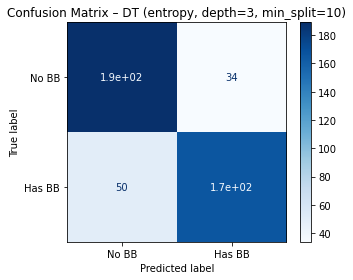

TN=189  FP=34
FN=50  TP=166


In [7]:
y_pred = dt_q2.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No BB', 'Has BB'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title("Confusion Matrix – DT (entropy, depth=3, min_split=10)")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f"TN={TN}  FP={FP}")
print(f"FN={FN}  TP={TP}")

**Answer Q3:** The confusion matrix is:

|               | Predicted 0 | Predicted 1 |
|---------------|-------------|-------------|
| **Actual 0**  | 189 (TN)    | 34 (FP)     |
| **Actual 1**  | 50 (FN)     | 166 (TP)    |

---
## Question 4 – Manual F1 Score

In [8]:
# Manual calculation
TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)

print(f"TP = {TP}, FP = {FP}, FN = {FN}, TN = {TN}")
print(f"Precision = {TP} / ({TP} + {FP}) = {precision:.4f}")
print(f"Recall    = {TP} / ({TP} + {FN}) = {recall:.4f}")
print(f"F1        = 2 × {precision:.4f} × {recall:.4f} / ({precision:.4f} + {recall:.4f}) = {f1:.4f}")
print(f"\nsklearn F1 (sanity check): {f1_score(y_test, y_pred):.4f}")

TP = 166, FP = 34, FN = 50, TN = 189
Precision = 166 / (166 + 34) = 0.8300
Recall    = 166 / (166 + 50) = 0.7685
F1        = 2 × 0.8300 × 0.7685 / (0.8300 + 0.7685) = 0.7981

sklearn F1 (sanity check): 0.7981


**Answer Q4:**
- Precision = 166 / (166 + 34) ≈ **0.8300**
- Recall    = 166 / (166 + 50) ≈ **0.7685**
- **F1 ≈ 0.7981**

---
## Question 5 – Random Forest GridSearch

In [9]:
k = 10

params_rf = {
    'n_estimators':      (5, 50, 100),
    'criterion':         ('gini', 'entropy'),
    'max_depth':         (1, 3, 5),
    'min_samples_split': (2, 5, 10),
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=0),
    params_rf, cv=k, scoring='accuracy', n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print("Best RF parameters :", gs_rf.best_params_)
print("Best RF CV accuracy :", round(gs_rf.best_score_, 4))

Best RF parameters : {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Best RF CV accuracy : 0.8034


In [10]:
X_train.columns

Index(['pct_white', 'pct_black', 'median_income', 'pop_density', 'num_isp'], dtype='object')

In [11]:
# Answering Q5 Quiz (Diff parameters)

k = 10

params_rf = {
    'n_estimators':      (1, 10, 20),
    'criterion':         ('gini', 'entropy'),
    'max_depth':         (1, 3, 5),
    'min_samples_split': (2, 5, 10),
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=0),
    params_rf, cv=k, scoring='accuracy', n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print("Best RF parameters :", gs_rf.best_params_)
print("Best RF CV accuracy :", round(gs_rf.best_score_, 4))

Best RF parameters : {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 20}
Best RF CV accuracy : 0.7994


**Answer Q5:** Best hyperparameters:  
`{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}`  
Best CV accuracy ≈ **0.8034** (80.3 %).

---
## Question 6 – Precision-Recall Curve

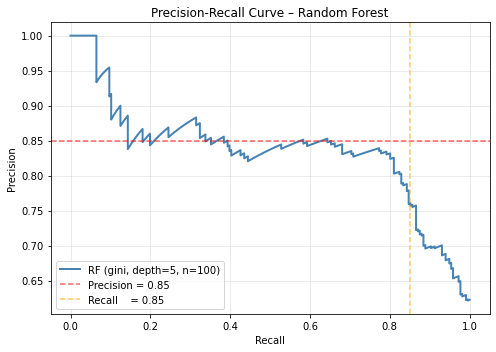

Default threshold (0.5) scores on test set:
  Precision : 0.7956
  Recall    : 0.8287
  F1        : 0.8118


In [12]:
from sklearn.metrics import precision_recall_curve

# Train RF with the specified best parameters
rf_q6 = RandomForestClassifier(
    criterion='gini', max_depth=5, min_samples_split=5,
    n_estimators=100, random_state=0
)
rf_q6.fit(X_train, y_train)

# Get predicted probabilities for the positive class (class 1)
y_proba = rf_q6.predict_proba(X_test)[:, 1]

# Compute precision-recall values across thresholds
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color='steelblue', lw=2, label='RF (gini, depth=5, n=100)')
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve – Random Forest")
ax.axhline(0.85, color='red',    linestyle='--', alpha=0.6, label='Precision = 0.85')
ax.axvline(0.85, color='orange', linestyle='--', alpha=0.6, label='Recall    = 0.85')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Default (0.5 threshold) scores for reference
y_pred_rf = rf_q6.predict(X_test)
print("Default threshold (0.5) scores on test set:")
print(f"  Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall    : {recall_score(y_test,    y_pred_rf):.4f}")
print(f"  F1        : {f1_score(y_test,         y_pred_rf):.4f}")

**Answer Q6:**  
From the curve, a good balance between precision and recall is achievable around **precision ≈ 0.85, recall ≈ 0.85**. The curve is relatively flat in this region, meaning small threshold changes don't heavily penalise either metric—making it a practical "sweet spot" to target.